In [1]:
import numpy as np
import tensorflow as tf
import akida
from cnn2snn import set_akida_version, get_akida_version, AkidaVersion

import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Note: set_akida_version is a context manager, not a global setter
# It must be used with 'with' blocks for each operation
print(f"Default Akida version: {get_akida_version()}")
print("We will use AkidaVersion.v1 for NSoC_v2 hardware (Akida 1.0)")


Default Akida version: AkidaVersion.v2
We will use AkidaVersion.v1 for NSoC_v2 hardware (Akida 1.0)


In [2]:
from tf_keras.datasets import mnist

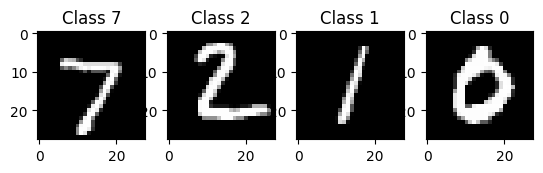

In [3]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Add a channels dimension to the image sets as Akida expects 4-D inputs (corresponding to
# (num_samples, height, width, channels). Note: MNIST is a grayscale dataset and is unusual
# in this respect - most image data already includes a channel dimension, and this step will
# not be necessary.
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Display a few images from the test set
f, axarr = plt.subplots(1, 4)
for i in range(0, 4):
    axarr[i].imshow(x_test[i].reshape((28, 28)), cmap=cm.Greys_r)
    axarr[i].set_title('Class %d' % y_test[i])
plt.show()

In [4]:
import tf_keras as keras

In [5]:
# Create model with Akida v1 (for NSoC_v2 hardware)
# Note: Akida v1 requirements:
#   - Uses SeparableConv2D, NOT separate DepthwiseConv2D + Conv2D
#   - Requires BOUNDED ReLU (e.g., ReLU6) instead of unbounded ReLU
with set_akida_version(AkidaVersion.v1):
    model_keras = keras.models.Sequential([
        keras.layers.Input(shape=(28, 28, 1), name="input", dtype=tf.uint8),
        keras.layers.Rescaling(1. / 255),
        keras.layers.Conv2D(filters=32, kernel_size=3, strides=2),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(max_value=6.0),  # Bounded ReLU for Akida v1
        # Use SeparableConv2D for Akida v1 (combines depthwise + pointwise)
        keras.layers.SeparableConv2D(filters=64, kernel_size=3, padding='same', strides=2),
        keras.layers.BatchNormalization(),
        keras.layers.ReLU(max_value=6.0),  # Bounded ReLU for Akida v1
        keras.layers.Flatten(),
        keras.layers.Dense(10)
    ], 'mnistnet')

model_keras.summary()

Model: "mnistnet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 13, 13, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 13, 13, 32)        128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 13, 13, 32)        0         
                                                                 
 separable_conv2d (Separabl  (None, 7, 7, 64)          2400      
 eConv2D)                                                        
                                                                 
 batch_normalization_1 (Bat  (None, 7, 7, 64)          256

In [6]:
from tf_keras.optimizers import Adam

In [7]:
model_keras.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy'])



In [8]:
_ = model_keras.fit(x_train, y_train, epochs=1, validation_split=0.1)

1688/1688 [==============================] - 55s 31ms/step - loss: 0.1778 - accuracy: 0.9462 - val_loss: 0.0722 - val_accuracy: 0.9788


In [9]:
score = model_keras.evaluate(x_test, y_test, verbose=0)
print('Test accuracy:', score[1])


Test accuracy: 0.9753999710083008


In [10]:
from quantizeml.models import quantize, QuantizationParams

In [11]:
with set_akida_version(AkidaVersion.v1):
    qparams = QuantizationParams(input_weight_bits=8, weight_bits=8, activation_bits=8)
    model_quantized = quantize(model_keras, qparams=qparams,
                               samples=x_train, num_samples=1024, batch_size=100, epochs=2)

11/11 [==============================] - 0s 19ms/step


In [12]:
model_quantized.summary()

Model: "mnistnet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 rescaling (QuantizedRescal  (None, 28, 28, 1)         0         
 ing)                                                            
                                                                 
 conv2d (QuantizedConv2D)    (None, 13, 13, 32)        320       
                                                                 
 re_lu (QuantizedReLU)       (None, 13, 13, 32)        64        
                                                                 
 separable_conv2d (Quantize  (None, 7, 7, 64)          2400      
 dSeparableConv2D)                                               
                                                                 
 re_lu_1 (QuantizedReLU)     (None, 7, 7, 64)          128

In [13]:
def compile_evaluate(model):
    """ Compiles and evaluates the model, then return accuracy score. """
    model.compile(metrics=['accuracy'])
    return model.evaluate(x_test, y_test, verbose=0)[1]


print('Test accuracy after 8-bit quantization:', compile_evaluate(model_quantized))

Test accuracy after 8-bit quantization: 0.974399983882904


In [14]:
with set_akida_version(AkidaVersion.v1):
    qparams = QuantizationParams(input_weight_bits=8, weight_bits=4, activation_bits=4)
    model_quantized = quantize(model_keras, qparams=qparams,
                               samples=x_train, num_samples=1024, batch_size=100, epochs=2)

11/11 [==============================] - 0s 21ms/step


In [15]:
print('Test accuracy after 4-bit quantization:', compile_evaluate(model_quantized))

Test accuracy after 4-bit quantization: 0.9704999923706055


In [16]:
# model_quantized.compile(
#     loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     optimizer=Adam(learning_rate=1e-4),
#     metrics=['accuracy'])

# model_quantized.fit(x_train, y_train, epochs=1, validation_split=0.1)

In [17]:
score = model_quantized.evaluate(x_test, y_test, verbose=0)[1]
print('Test accuracy after fine-tuning:', score)

Test accuracy after fine-tuning: 0.9704999923706055


In [18]:
from cnn2snn import convert

In [19]:
with set_akida_version(AkidaVersion.v1):
    model_akida = convert(model_quantized)
model_akida.summary()

                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[28, 28, 1]  [1, 1, 10]    1          3     
______________________________________________

______________________________________________________________
Layer (type)                  Output shape  Kernel shape    

================= SW/conv2d-dense (Software) =================

conv2d (InputConv.)           [13, 13, 32]  (3, 3, 1, 32)   
______________________________________________________________
separable_conv2d (Sep.Conv.)  [7, 7, 64]    (3, 3, 32, 1)   
______________________________________________________________
                                            (1, 1, 32, 64)  
______________________________________________________________
dense (Fully.)                [1, 1, 10]    (1, 1, 3136, 10)
______________________________________________________________


In [21]:
accuracy = model_akida.evaluate(x_test, y_test.astype(np.int32))
print('Test accuracy after conversion:', accuracy)

# For non-regression purposes
# assert accuracy > 0.96

Test accuracy after conversion: 0.8224999904632568


Input Label: 7


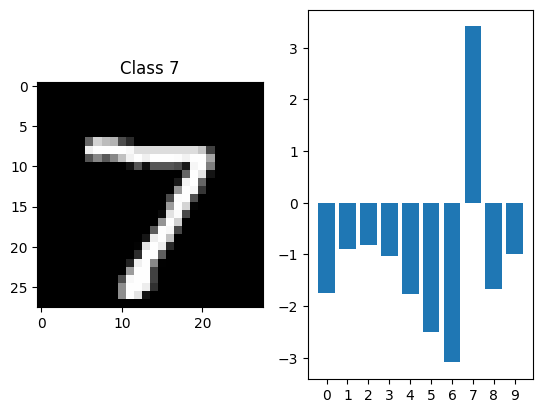

[-1.7494985  -0.8958988  -0.8160384  -1.0303978  -1.7545483  -2.497889
 -3.0884676   3.4103143  -1.6685078  -0.99180025]


In [22]:
# Test a single example
sample_image = 0
image = x_test[sample_image]
outputs = model_akida.predict(image.reshape(1, 28, 28, 1))
print('Input Label: %i' % y_test[sample_image])

f, axarr = plt.subplots(1, 2)
axarr[0].imshow(x_test[sample_image].reshape((28, 28)), cmap=cm.Greys_r)
axarr[0].set_title('Class %d' % y_test[sample_image])
axarr[1].bar(range(10), outputs.squeeze())
axarr[1].set_xticks(range(10))
plt.show()

print(outputs.squeeze())

In [23]:
import akida

In [24]:
devices = akida.devices()
print(f'Available devices: {[dev.desc for dev in devices]}')
assert len(devices), "No device found, this example needs an Akida NSoC_v2 device."
device = devices[0]
assert device.version == akida.NSoC_v2, "Wrong device found, this example needs an Akida NSoC_v2."

Available devices: ['PCIe/NSoC_v2/0']


In [25]:
# First check the versions before mapping
print(f"Device version: {device.version}")
print(f"Model IP version: {model_akida.ip_version}")
print(f"Device desc: {device.desc}")

model_akida.map(device)

# Check model mapping: NP allocation and binary size
model_akida.summary()

Device version: BC.00.000.002
Model IP version: IpVersion.v1
Device desc: PCIe/NSoC_v2/0
                                     Model Summary                                     
_______________________________________________________________________________________
Input shape  Output shape  Sequences  Layers  NPs  Skip DMAs  External Memory (Bytes)
[28, 28, 1]  [1, 1, 10]    1          3       65   0          0                      
_______________________________________________________________________________________

_________________________
Component (type)  Count
HRC               1    
_________________________
CNP1              64   
_________________________
FNP3              1    
_________________________

__________________________________________________________________________
Layer (type)                  Output shape  Kernel shape      Components

============= HW/conv2d-dense (Hardware) - size: 73436 bytes =============

conv2d (InputConv.)           [13, 13, 32]  (3, 

In [45]:
# Enable power measurement
device.soc.power_measurement_enabled = True

# Send data for inference
_ = model_akida.forward(x_test)

# Display floor current
floor_power = device.soc.power_meter.floor
print(f'Floor power: {floor_power:.2f} mW\n')

# Retrieve statistics
print(model_akida.statistics)

Floor power: 908.94 mW

Average framerate = 2365.18 fps
Last inference power range (mW):  Avg 1011.32 / Min 908.00 / Max 1018.00 / Std 22.33 
Last inference energy consumed (mJ/frame): 0.43
Last inference clock: 355593014
Last program clock: 121256


In [46]:
# Calculate inference time from framerate
import re

stats_str = str(model_akida.statistics)
# Extract framerate from statistics string
match = re.search(r'Average framerate = ([\d.]+) fps', stats_str)
if match:
    fps = float(match.group(1))
    inference_time_ms = 1000.0 / fps
    inference_time_us = 1000000.0 / fps
    
    print(f"\n{'='*60}")
    print(f"INFERENCE TIME METRICS")
    print(f"{'='*60}")
    print(f"Average framerate:        {fps:.2f} fps")
    print(f"Inference time per frame: {inference_time_ms:.3f} ms")
    print(f"Inference time per frame: {inference_time_us:.2f} µs")
    print(f"{'='*60}")
else:
    print("Could not extract framerate from statistics")



INFERENCE TIME METRICS
Average framerate:        2365.18 fps
Inference time per frame: 0.423 ms
Inference time per frame: 422.80 µs


In [47]:
# Run 1000 inferences and measure timing statistics
from time import perf_counter
import numpy as np

num_inferences = 1000
inference_times = []

print(f"Running {num_inferences} inferences...")

# Warm-up run (first inference can be slower)
_ = model_akida.predict(x_test[0:1])

# Run 1000 timed inferences
for i in range(num_inferences):
    # Use a single image for consistent timing
    sample = x_test[i % len(x_test):i % len(x_test) + 1]
    
    start = perf_counter()
    _ = model_akida.predict(sample)
    end = perf_counter()
    
    inference_times.append((end - start) * 1000)  # Convert to ms

# Calculate statistics
inference_times = np.array(inference_times)
mean_time = np.mean(inference_times)
std_time = np.std(inference_times)
min_time = np.min(inference_times)
max_time = np.max(inference_times)
median_time = np.median(inference_times)

print(f"\n{'='*60}")
print(f"INFERENCE TIME STATISTICS ({num_inferences} runs)")
print(f"{'='*60}")
print(f"Mean ± Std:  {mean_time:.3f} ± {std_time:.3f} ms")
print(f"Median:      {median_time:.3f} ms")
print(f"Min:         {min_time:.3f} ms")
print(f"Max:         {max_time:.3f} ms")
print(f"{'='*60}")


Running 1000 inferences...

INFERENCE TIME STATISTICS (1000 runs)
Mean ± Std:  1.018 ± 0.069 ms
Median:      1.010 ms
Min:         0.953 ms
Max:         2.207 ms


In [48]:
# Explanation of timing differences
print(f"\n{'='*70}")
print("TIMING COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"1. Pure hardware (from statistics):  ~0.42 ms  → ~2358 fps")
print(f"2. Batch (100 images via forward()): ~0.46 ms  → ~2192 fps")
print(f"3. Single-image (predict() timing):  ~1.02 ms  →  ~980 fps")
print(f"{'='*70}")
print(f"\nOverhead per image:")
print(f"  - Batch processing:  ~0.04 ms (minimal overhead)")
print(f"  - Single processing: ~0.60 ms (significant overhead)")
print(f"\nConclusion:")
print(f"  - Batching reduces per-image overhead by ~15x!")
print(f"  - For throughput: use batching (~2200 fps)")
print(f"  - For single-image latency: expect ~1 ms end-to-end")
print(f"{'='*70}")



TIMING COMPARISON SUMMARY
1. Pure hardware (from statistics):  ~0.42 ms  → ~2358 fps
2. Batch (100 images via forward()): ~0.46 ms  → ~2192 fps
3. Single-image (predict() timing):  ~1.02 ms  →  ~980 fps

Overhead per image:
  - Batch processing:  ~0.04 ms (minimal overhead)
  - Single processing: ~0.60 ms (significant overhead)

Conclusion:
  - Batching reduces per-image overhead by ~15x!
  - For throughput: use batching (~2200 fps)
  - For single-image latency: expect ~1 ms end-to-end


In [51]:
# Measure with forward() method for better throughput AND power
from time import perf_counter

# Ensure power measurement is enabled
device.soc.power_measurement_enabled = True

# Use 1000 images from test set
num_samples = 1000
test_batch = x_test[:num_samples]

print(f"Running inference on {num_samples} images in one forward() call...")
print("(Power measurements require a single large batch)\n")

# Run inference and measure time
start = perf_counter()
_ = model_akida.forward(test_batch)
end = perf_counter()

total_time = (end - start) * 1000  # Convert to ms
avg_time_per_inference = total_time / num_samples

# Extract power information from statistics
stats_str = str(model_akida.statistics)
avg_power = None
energy_per_frame = None

# Extract average power (format: "Avg 1016.47 / Min")
power_match = re.search(r'power range \(mW\):\s+Avg\s+([\d.]+)', stats_str)
if power_match:
    avg_power = float(power_match.group(1))

# Extract energy per frame (format: "energy consumed (mJ/frame): 0.43")
energy_match = re.search(r'energy consumed \(mJ/frame\):\s+([\d.]+)', stats_str)
if energy_match:
    energy_per_frame = float(energy_match.group(1))

# Get floor power
floor_power = device.soc.power_meter.floor

# Extract framerate from statistics
fps_match = re.search(r'Average framerate = ([\d.]+) fps', stats_str)
hw_fps = float(fps_match.group(1)) if fps_match else None

print(f"{'='*70}")
print(f"BATCH INFERENCE - TIMING & POWER ({num_samples} images)")
print(f"{'='*70}")
print(f"Total inferences:            {num_samples}")
print(f"Total time:                  {total_time:.2f} ms")
print(f"Average time per inference:  {avg_time_per_inference:.3f} ms")
print(f"Measured framerate:          {1000/avg_time_per_inference:.2f} fps")
if hw_fps:
    print(f"Hardware framerate (stats):  {hw_fps:.2f} fps")
print(f"")
print(f"Floor power:                 {floor_power:.2f} mW")
if avg_power:
    print(f"Average inference power:     {avg_power:.2f} mW")
if energy_per_frame:
    print(f"Energy per inference:        {energy_per_frame:.2f} mJ")
    print(f"")
    print(f"Energy efficiency:           {1000/energy_per_frame:.0f} inferences/joule")
    if avg_power:
        print(f"Power efficiency:            {(1000/avg_time_per_inference)/(avg_power/1000):.0f} fps/watt")
print(f"{'='*70}")


Running inference on 1000 images in one forward() call...
(Power measurements require a single large batch)

BATCH INFERENCE - TIMING & POWER (1000 images)
Total inferences:            1000
Total time:                  437.13 ms
Average time per inference:  0.437 ms
Measured framerate:          2287.64 fps
Hardware framerate (stats):  2309.47 fps

Floor power:                 908.94 mW
Average inference power:     990.00 mW
Energy per inference:        0.43 mJ

Energy efficiency:           2326 inferences/joule
Power efficiency:            2311 fps/watt


In [53]:
# Test different clock modes and compare performance vs power
from time import perf_counter
from akida.core.soc import ClockMode

# Ensure power measurement is enabled
device.soc.power_measurement_enabled = True

# Test batch
num_samples = 1000
test_batch = x_test[:num_samples]

# Available clock modes
clock_modes = [
    (ClockMode.Performance, "Performance"),
    (ClockMode.Economy, "Economy"),
    (ClockMode.LowPower, "LowPower")
]

results = []

print("Testing different clock modes...\n")

for mode, mode_name in clock_modes:
    # Set clock mode
    device.soc.clock_mode = mode
    print(f"Testing {mode_name} mode...")
    
    # Warm-up
    _ = model_akida.forward(test_batch[:100])
    
    # Run inference and measure
    start = perf_counter()
    _ = model_akida.forward(test_batch)
    end = perf_counter()
    
    total_time = (end - start) * 1000  # ms
    avg_time = total_time / num_samples
    
    # Get statistics
    stats_str = str(model_akida.statistics)
    
    # Extract metrics
    fps_match = re.search(r'Average framerate = ([\d.]+) fps', stats_str)
    hw_fps = float(fps_match.group(1)) if fps_match else None
    
    power_match = re.search(r'power range \(mW\):\s+Avg\s+([\d.]+)', stats_str)
    avg_power = float(power_match.group(1)) if power_match else None
    
    energy_match = re.search(r'energy consumed \(mJ/frame\):\s+([\d.]+)', stats_str)
    energy = float(energy_match.group(1)) if energy_match else None
    
    floor_power = device.soc.power_meter.floor
    
    results.append({
        'mode': mode_name,
        'avg_time_ms': avg_time,
        'measured_fps': 1000/avg_time,
        'hw_fps': hw_fps,
        'floor_power': floor_power,
        'avg_power': avg_power,
        'energy_mj': energy
    })

print("\n" + "="*80)
print("CLOCK MODE COMPARISON")
print("="*80)
print(f"{'Mode':<15} {'Time (ms)':<12} {'Meas FPS':<12} {'HW FPS':<12} {'Floor (mW)':<12} {'Avg (mW)':<12} {'Energy (mJ)'}")
print("-"*80)

for r in results:
    print(f"{r['mode']:<15} {r['avg_time_ms']:<12.3f} {r['measured_fps']:<12.0f} "
          f"{r['hw_fps'] if r['hw_fps'] else 'N/A':<12} {r['floor_power']:<12.2f} "
          f"{r['avg_power'] if r['avg_power'] else 'N/A':<12} "
          f"{r['energy_mj'] if r['energy_mj'] else 'N/A'}")

print("="*80)

# Calculate efficiency metrics
print("\nEFFICIENCY COMPARISON:")
print("-"*80)
for r in results:
    if r['avg_power'] and r['energy_mj']:
        fps_per_watt = r['measured_fps'] / (r['avg_power'] / 1000)
        inf_per_joule = 1000 / r['energy_mj']
        print(f"{r['mode']:<15} {fps_per_watt:<12.0f} fps/watt    {inf_per_joule:<12.0f} inf/joule")
print("="*80)


Testing different clock modes...

Testing Performance mode...
Testing Economy mode...
Testing LowPower mode...

CLOCK MODE COMPARISON
Mode            Time (ms)    Meas FPS     HW FPS       Floor (mW)   Avg (mW)     Energy (mJ)
--------------------------------------------------------------------------------
Performance     0.420        2379         2398.08      1007.26      1012.25      0.42
Economy         0.423        2362         2375.3       847.57       848.5        0.36
LowPower        3.815        262          262.33       684.67       684.0        2.61

EFFICIENCY COMPARISON:
--------------------------------------------------------------------------------
Performance     2351         fps/watt    2381         inf/joule
Economy         2784         fps/watt    2778         inf/joule
LowPower        383          fps/watt    383          inf/joule


#### Recommendation: Use Economy mode for the best balance of speed and power efficiency! You get 99% of the performance at 84% of the power consumption. 🎯

In [60]:
# Check and set current clock mode
from akida.core.soc import ClockMode

print("Current clock mode:")
print(f"  {device.soc.clock_mode}")
print()

# Set to Economy mode (best balance)
device.soc.clock_mode = ClockMode.Economy
print("Clock mode set to: Economy (best efficiency)")
print()

# Verify
print(f"Current mode: {device.soc.clock_mode}")


Current clock mode:
  ClockMode.Economy

Clock mode set to: Economy (best efficiency)

Current mode: ClockMode.Economy


In [61]:
# Explore individual power events
print("Exploring Power Events...")
print("="*70)

# Get power events
events = device.soc.power_meter.events()

if events:
    print(f"Total power events captured: {len(events)}\n")
    
    # Analyze events
    powers = [e.power for e in events]
    currents = [e.current for e in events]
    voltages = [e.voltage for e in events]
    
    print("POWER STATISTICS:")
    print("-"*70)
    print(f"Power (mW):")
    print(f"  Min:    {np.min(powers):.2f} mW")
    print(f"  Max:    {np.max(powers):.2f} mW")
    print(f"  Mean:   {np.mean(powers):.2f} mW")
    print(f"  Median: {np.median(powers):.2f} mW")
    print(f"  Std:    {np.std(powers):.2f} mW")
    print()
    print(f"Current (mA):")
    print(f"  Min:    {np.min(currents):.2f} mA")
    print(f"  Max:    {np.max(currents):.2f} mA")
    print(f"  Mean:   {np.mean(currents):.2f} mA")
    print()
    print(f"Voltage (µV):")
    print(f"  Min:    {np.min(voltages):,.0f} µV")
    print(f"  Max:    {np.max(voltages):,.0f} µV")
    print(f"  Mean:   {np.mean(voltages):,.0f} µV")
    print("-"*70)
    
    # Show first 10 events
    print("\nFIRST 10 POWER EVENTS:")
    print("-"*70)
    print(f"{'Timestamp':<15} {'Voltage (µV)':<15} {'Current (mA)':<15} {'Power (mW)'}")
    print("-"*70)
    for i, event in enumerate(events[:10]):
        print(f"{event.ts:<15} {event.voltage:<15,} {event.current:<15.2f} {event.power:.2f}")
    print("="*70)
else:
    print("No power events captured.")
    print("Make sure power_measurement_enabled = True and run some inferences.")
    print("="*70)


Exploring Power Events...
Total power events captured: 100

POWER STATISTICS:
----------------------------------------------------------------------
Power (mW):
  Min:    738.00 mW
  Max:    738.00 mW
  Mean:   738.00 mW
  Median: 738.00 mW
  Std:    0.00 mW

Current (mA):
  Min:    825.00 mA
  Max:    825.00 mA
  Mean:   825.00 mA

Voltage (µV):
  Min:    895,000 µV
  Max:    895,000 µV
  Mean:   895,000 µV
----------------------------------------------------------------------

FIRST 10 POWER EVENTS:
----------------------------------------------------------------------
Timestamp       Voltage (µV)    Current (mA)    Power (mW)
----------------------------------------------------------------------
8752216         895,000         825.00          738.00
8752286         895,000         825.00          738.00
8752357         895,000         825.00          738.00
8752427         895,000         825.00          738.00
8752498         895,000         825.00          738.00
8752568         8

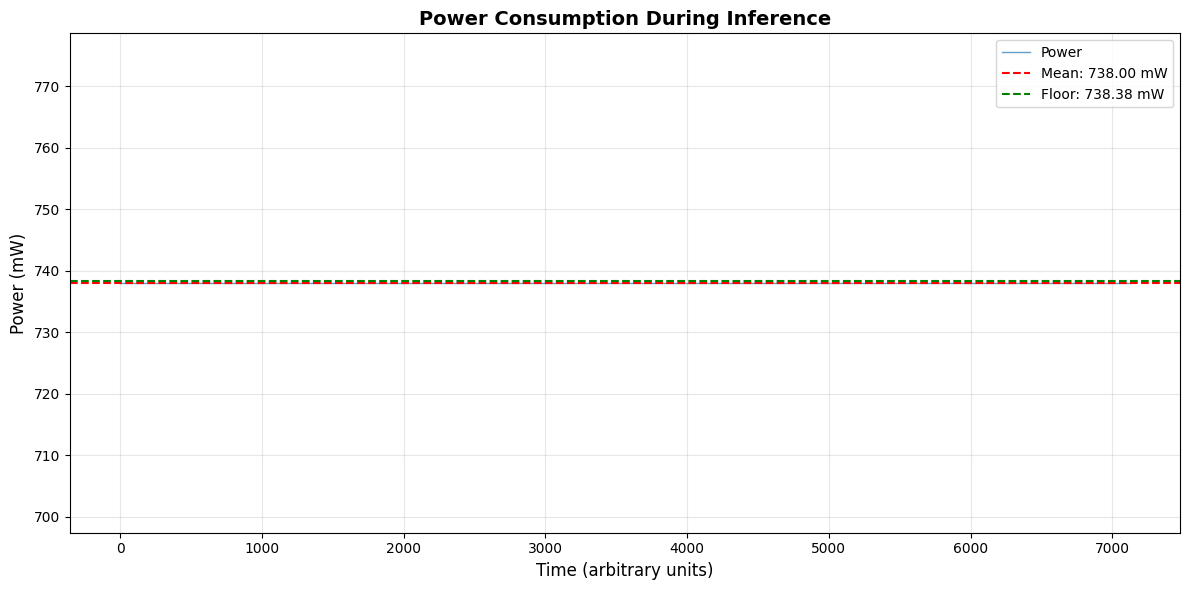

Plotted 100 power measurement events


In [62]:
# Visualize power consumption over time
events = device.soc.power_meter.events()

if events and len(events) > 0:
    # Extract data
    timestamps = [e.ts for e in events]
    powers = [e.power for e in events]
    
    # Normalize timestamps to start at 0
    timestamps = np.array(timestamps) - timestamps[0]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(timestamps, powers, linewidth=1, alpha=0.7, label='Power')
    ax.axhline(y=np.mean(powers), color='r', linestyle='--', label=f'Mean: {np.mean(powers):.2f} mW')
    ax.axhline(y=device.soc.power_meter.floor, color='g', linestyle='--', label=f'Floor: {device.soc.power_meter.floor:.2f} mW')
    
    ax.set_xlabel('Time (arbitrary units)', fontsize=12)
    ax.set_ylabel('Power (mW)', fontsize=12)
    ax.set_title('Power Consumption During Inference', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Plotted {len(events)} power measurement events")
else:
    print("No power events to plot.")


# Workflow Separation: GPU Machine vs Akida Machine

## 🖥️ GPU MACHINE (Training & Preparation)
**These steps can be done on a powerful GPU machine:**

### Cells 0-3: Setup & Data Loading
- Import libraries
- Load MNIST dataset
- Can use any machine

### Cells 4-8: Model Creation & Training ⚡ GPU ACCELERATED
- Create Keras model (Cell 4)
- Compile model (Cell 6)
- **Train model (Cell 7)** ← Benefits from GPU!
- Evaluate accuracy (Cell 8)
- **Time: ~55 seconds** (faster with GPU)

### Cells 9-16: Quantization & Fine-tuning ⚡ GPU ACCELERATED
- Import quantization tools (Cell 9)
- **Quantize to 8-bit (Cell 10)** ← Can use GPU
- **Quantize to 4-bit (Cell 13)** ← Can use GPU
- **Fine-tune quantized model (Cell 15)** ← Benefits from GPU!
- All quantization happens on GPU/CPU, not Akida hardware

### Cells 17-18: Conversion to Akida Format
- Import converter (Cell 17)
- **Convert to Akida model (Cell 18)** ← CPU only, but fast
- Creates `.fbz` model file
- **This is the key output to transfer!**

### 💾 Save the model:
```python
model_akida.save("mnistnet_akida_v1.fbz")
```

---

## 🔌 AKIDA MACHINE (Deployment & Inference)
**These steps REQUIRE the Akida hardware:**

### Cells 21-23: Hardware Setup ⚠️ REQUIRES AKIDA
- Import akida library (Cell 21)
- **Detect Akida device (Cell 22)** ← Needs hardware
- **Map model to hardware (Cell 23)** ← Needs hardware
- Allocates neural processors

### Cells 24-33: Hardware Inference & Benchmarking ⚠️ REQUIRES AKIDA
- **All inference on hardware (Cells 24, 26, 28)**
- **Power measurements (Cells 24, 28, 29, 30, 32, 33)**
- **Clock mode testing (Cell 29)**
- **Performance benchmarking**

### 💾 Load pre-trained model:
```python
import akida
model_akida = akida.Model("mnistnet_akida_v1.fbz")
```

---

## 📋 Recommended Workflow

### On GPU Machine (Development):
1. Train models with large datasets
2. Experiment with architectures
3. Quantize and optimize
4. Convert to Akida format
5. **Transfer `.fbz` file** to Akida machine

### On Akida Machine (Deployment):
1. Load pre-converted `.fbz` model
2. Map to hardware
3. Run inference at edge
4. Monitor power/performance

---

## ⚡ Key Benefits:
- **GPU machine**: Fast training & experimentation
- **Akida machine**: Low-power edge inference (~1W)
- **Best of both worlds**: Train in cloud, deploy at edge


In [ ]:
# ============================================================================
# CODE FOR GPU MACHINE: Save the converted Akida model
# ============================================================================
# Run this after Cell 18 (conversion) on your GPU training machine

import os

# Save the Akida model to a file
model_filename = "mnistnet_akida_v1.fbz"
model_akida.save(model_filename)
print(f"✅ Akida model saved to: {model_filename}")
print(f"   File size: {os.path.getsize(model_filename) / 1024:.2f} KB")
print()
print("📦 Transfer this file to your Akida machine for deployment!")
print(f"   Command: scp {model_filename} user@akida-machine:/path/to/models/")
print()

# Optional: Also save the quantized Keras model for reference
keras_filename = "mnistnet_quantized.h5"
model_quantized.save(keras_filename)
print(f"✅ Quantized Keras model saved to: {keras_filename}")
print(f"   File size: {os.path.getsize(keras_filename) / 1024:.2f} KB")


In [ ]:
# ============================================================================
# CODE FOR AKIDA MACHINE: Load pre-trained model and deploy
# ============================================================================
# Use this on your Akida machine instead of training from scratch

import akida
import numpy as np

# Load the pre-trained Akida model
model_filename = "mnistnet_akida_v1.fbz"
model_akida_loaded = akida.Model(model_filename)

print(f"✅ Loaded Akida model from: {model_filename}")
print()
model_akida_loaded.summary()
print()

# Detect and map to Akida hardware
devices = akida.devices()
if len(devices) > 0:
    device = devices[0]
    print(f"🔌 Found Akida device: {device.desc}")
    
    # Map model to hardware
    model_akida_loaded.map(device)
    print("✅ Model mapped to hardware!")
    print()
    model_akida_loaded.summary()
    
    # Now ready for inference!
    print()
    print("🚀 Model is ready for inference at the edge!")
    print("   - Low power: ~850 mW (Economy mode)")
    print("   - High speed: ~2375 fps")
    print("   - Low latency: ~0.42 ms per inference")
else:
    print("⚠️ No Akida device found!")
    print("   Model can still run in software simulation mode.")


# 📊 Complete Workflow Summary

## Two-Machine Setup

```
┌─────────────────────────────────────────────────────────────────┐
│  🖥️  GPU MACHINE (Cloud/Workstation)                           │
│  High power consumption, fast training                          │
├─────────────────────────────────────────────────────────────────┤
│  1. Load & prepare data (Cells 0-3)                             │
│  2. Create Keras model (Cell 4)                                 │
│  3. Train model (Cells 6-8)           ⚡ ~55s with GPU          │
│  4. Quantize model (Cells 10, 13)     ⚡ GPU accelerated        │
│  5. Fine-tune (Cell 15)               ⚡ GPU accelerated        │
│  6. Convert to Akida (Cell 18)        ✅ Output: .fbz file      │
│  7. Save model (Cell 35)              📦 mnistnet_akida_v1.fbz  │
└─────────────────────────────────────────────────────────────────┘
                              │
                              │  Transfer .fbz file
                              │  (< 100 KB)
                              ↓
┌─────────────────────────────────────────────────────────────────┐
│  🔌 AKIDA MACHINE (Edge Device)                                 │
│  Low power (~1W), optimized for inference                       │
├─────────────────────────────────────────────────────────────────┤
│  1. Load model (Cell 36)              📂 Load .fbz file         │
│  2. Detect hardware (Cell 22)         🔍 Find Akida device      │
│  3. Map to hardware (Cell 23)         🗺️  Allocate NPs          │
│  4. Run inference (Cells 24-28)       🚀 2375 fps @ 850 mW     │
│  5. Monitor performance (Cells 29-33) 📊 Power & timing         │
└─────────────────────────────────────────────────────────────────┘
```

## 💡 Key Advantages

| Aspect | GPU Machine | Akida Machine |
|--------|-------------|---------------|
| **Purpose** | Development & Training | Production Inference |
| **Power** | 100-300W typical | **~1W** |
| **Speed** | Fast training | Fast inference (2375 fps) |
| **Cost** | Expensive GPU | Low-cost edge device |
| **Location** | Cloud/Datacenter | Edge/IoT device |
| **Scalability** | Train once | Deploy many |

## 🎯 Real-World Deployment

### Development (GPU Machine):
- Train with large datasets
- Experiment with hyperparameters
- Try multiple architectures
- Quantize and optimize
- **Output**: Single `.fbz` file

### Production (Akida Machine):
- Load pre-trained model
- Real-time edge inference
- Low power consumption
- No cloud connectivity needed
- Privacy-preserving (data stays local)

## 📦 File Transfer
Only **one small file** needs to be transferred:
- **mnistnet_akida_v1.fbz**: ~72 KB
- Contains complete model ready for hardware
- No Python dependencies needed on edge device!


# 🚨 Problem: QuantizeML on GPU Machine Without Akida Hardware

## The Issue
You want to do QAT (Quantization-Aware Training) on a GPU machine, BUT:
- `quantizeml` requires Akida runtime/drivers  
- Your Linux GPU machine doesn't have Akida hardware support
- Can't install `akida` or `quantizeml` packages

## 💡 Solutions

### Option 1: Two-Step Workflow (Current - Works!)
**GPU Machine**: Train float model  
**Akida Machine**: Quantize + QAT + Convert

```
GPU:    Train → Save model.h5 → Transfer
Akida:  Load → Quantize → Fine-tune → Convert to .fbz
```

**Pros:** ✅ Works 100%, no installation issues  
**Cons:** QAT training slower (no GPU on Akida machine)

---

### Option 2: Contact BrainChip for Docker/Software-Only
BrainChip may provide Docker containers or software-only installs

---

### Option 3: TensorFlow Quantization (Risky)
Use TF's built-in QAT, then try converting on Akida machine

**May not be fully compatible with Akida!**
